In [104]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [106]:
# Load dataset

df = pd.read_csv("Zomato-data-.csv")

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [108]:
# Display project objective

print("""
OBJECTIVE

1. Analyze restaurant trends.
2. Analyze ratings and votes.
3. Study online ordering behavior.
4. Study table booking behavior.
5. Analyze restaurant costs.
6. Generate business insights.
""")


OBJECTIVE

1. Analyze restaurant trends.
2. Analyze ratings and votes.
3. Study online ordering behavior.
4. Study table booking behavior.
5. Analyze restaurant costs.
6. Generate business insights.



In [110]:
# Check dataset dimensions

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 148
Columns: 7


In [112]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [114]:
# Display all columns

df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [116]:
# Display column datatypes

df.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

In [118]:
# Count unique values in each column

df.nunique()

name                           145
online_order                     2
book_table                       2
rate                            20
votes                           90
approx_cost(for two people)     18
listed_in(type)                  4
dtype: int64

In [120]:
# Display sample values from each column

for col in df.columns:
    print("\n", col)
    print(df[col].unique()[:10])


 name
['Jalsa' 'Spice Elephant' 'San Churro Cafe' 'Addhuri Udupi Bhojana'
 'Grand Village' 'Timepass Dinner'
 'Rosewood International Hotel - Bar & Restaurant' 'Onesta'
 'Penthouse Cafe' 'Smacznego']

 online_order
['Yes' 'No']

 book_table
['Yes' 'No']

 rate
['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5']

 votes
[ 775  787  918   88  166  286    8 2556  324  504]

 approx_cost(for two people)
[800 300 600 700 550 500 450 650 400 900]

 listed_in(type)
['Buffet' 'Cafes' 'other' 'Dining']


In [122]:
# Check missing values

pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

,Missing Values,Percentage
name,0,0.0
online_order,0,0.0
book_table,0,0.0
rate,0,0.0
votes,0,0.0
approx_cost(for two people),0,0.0
listed_in(type),0,0.0


In [124]:
# Check duplicate rows

df.duplicated().sum()

0

In [126]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

df.shape

(148, 7)

In [128]:
# Generate statistical summary

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,148,145,San Churro Cafe,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_order,148,2,No,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
book_table,148,2,No,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate,148,20,3.8/5,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
votes,148.0,NaN,NaN,NaN,264.810811,653.676951,0.0,6.75,43.5,221.75,4884.0
approx_cost(for two people),148.0,NaN,NaN,NaN,418.243243,223.085098,100.0,200.0,400.0,600.0,950.0
listed_in(type),148,4,Dining,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
# Convert rating column into numeric format

df['rate'] = (
    df['rate']
    .astype(str)
    .str.replace('/5','',regex=False)
    .str.strip()
)

df['rate'] = pd.to_numeric(
    df['rate'],
    errors='coerce'
)

df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [132]:
# Analyze rating statistics

df['rate'].describe()

count    148.000000
mean       3.633108
std        0.402271
min        2.600000
25%        3.300000
50%        3.700000
75%        3.900000
max        4.600000
Name: rate, dtype: float64

In [134]:
# Count restaurant categories

df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

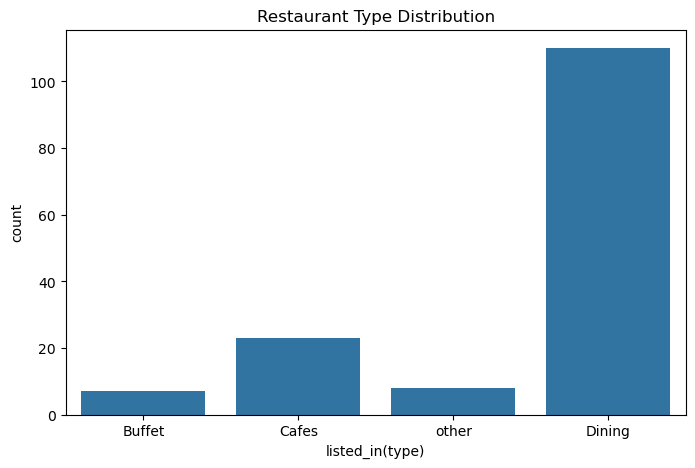

In [136]:
# Visualize restaurant categories

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='listed_in(type)'
)

plt.title("Restaurant Type Distribution")

plt.show()

In [138]:
# Analyze online order availability

df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

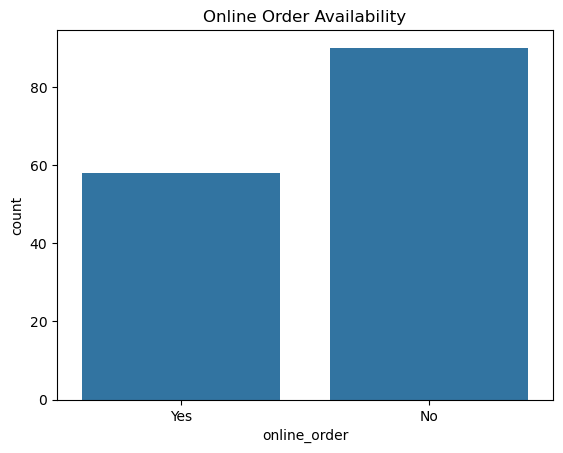

In [140]:
# Visualize online ordering

sns.countplot(
    data=df,
    x='online_order'
)

plt.title("Online Order Availability")

plt.show()

In [142]:
# Analyze table booking availability

df['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

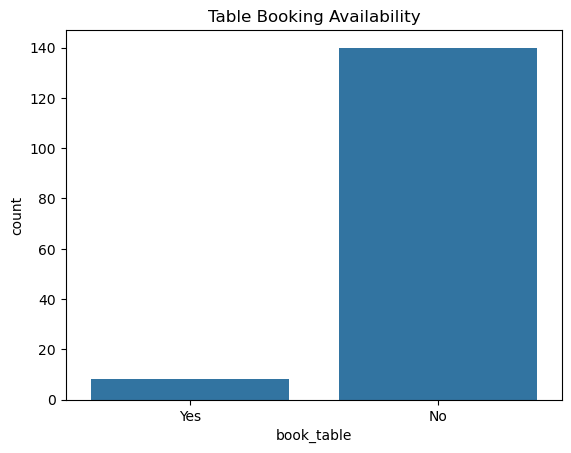

In [144]:
# Visualize table booking availability

sns.countplot(
    data=df,
    x='book_table'
)

plt.title("Table Booking Availability")

plt.show()

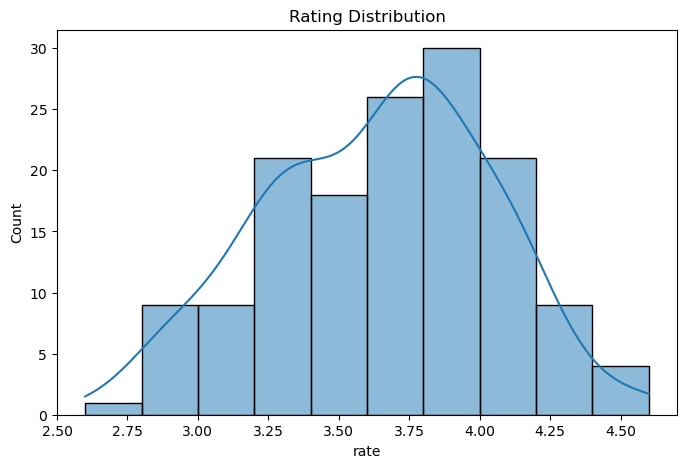

In [146]:
# Analyze rating distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['rate'],
    bins=10,
    kde=True
)

plt.title("Rating Distribution")

plt.show()

In [148]:
# Calculate average rating

round(df['rate'].mean(),2)

3.63

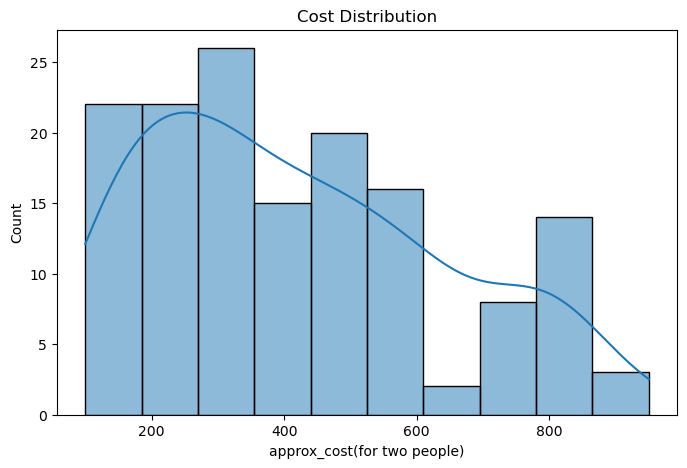

In [150]:
# Analyze restaurant cost distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['approx_cost(for two people)'],
    bins=10,
    kde=True
)

plt.title("Cost Distribution")

plt.show()

In [152]:
# Generate cost statistics

df['approx_cost(for two people)'].describe()

count    148.000000
mean     418.243243
std      223.085098
min      100.000000
25%      200.000000
50%      400.000000
75%      600.000000
max      950.000000
Name: approx_cost(for two people), dtype: float64

In [154]:
# Measure cost skewness

df['approx_cost(for two people)'].skew()

0.5002940102488174

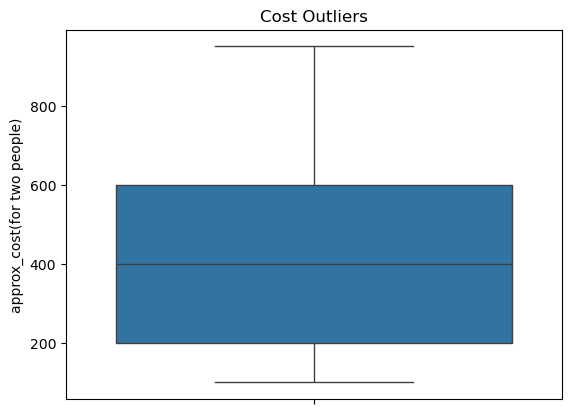

In [156]:
# Detect cost outliers

sns.boxplot(
    y=df['approx_cost(for two people)']
)

plt.title("Cost Outliers")

plt.show()

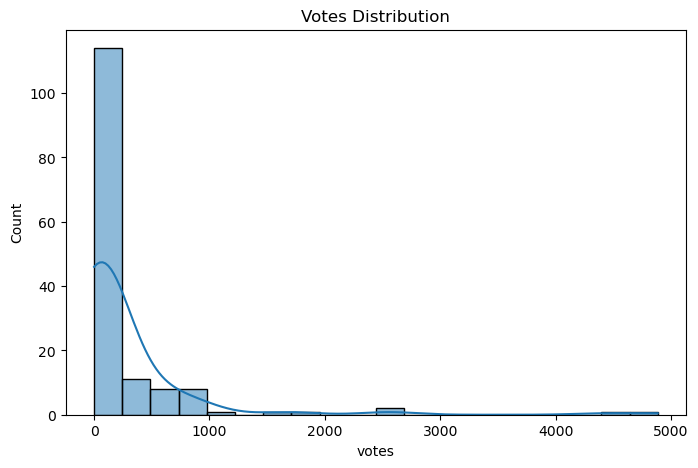

In [158]:
# Analyze votes distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['votes'],
    bins=20,
    kde=True
)

plt.title("Votes Distribution")

plt.show()

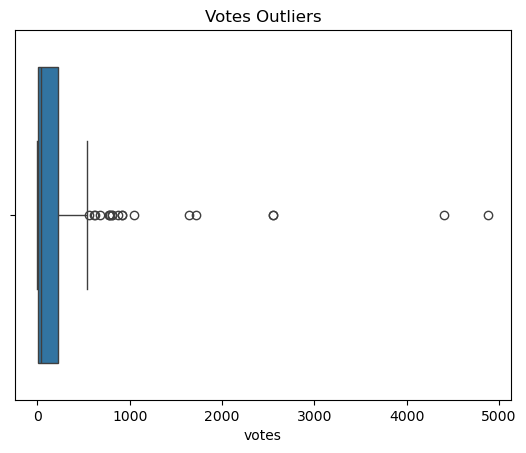

In [160]:
# Detect vote outliers

sns.boxplot(
    x=df['votes']
)

plt.title("Votes Outliers")

plt.show()

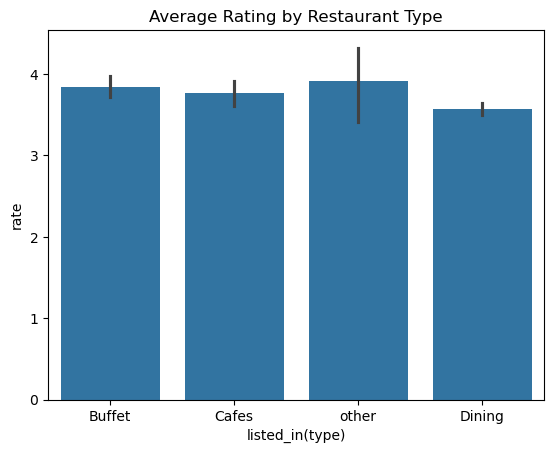

In [162]:
# Compare ratings across restaurant categories

sns.barplot(
    data=df,
    x='listed_in(type)',
    y='rate'
)

plt.title("Average Rating by Restaurant Type")

plt.show()

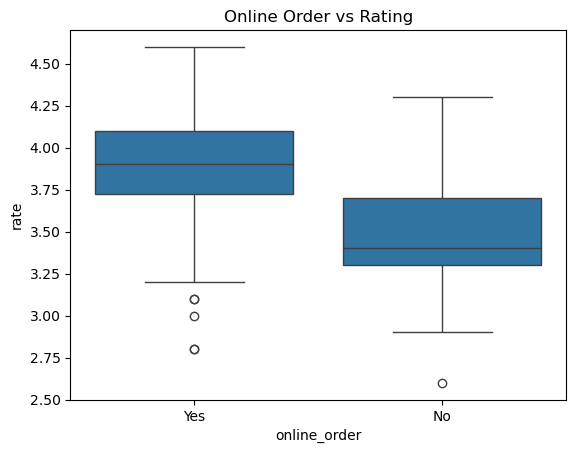

In [164]:
# Compare ratings by online ordering

sns.boxplot(
    data=df,
    x='online_order',
    y='rate'
)

plt.title("Online Order vs Rating")

plt.show()

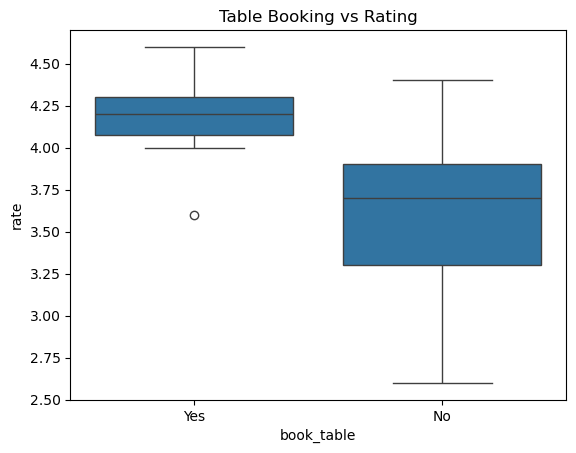

In [166]:
# Compare ratings by table booking

sns.boxplot(
    data=df,
    x='book_table',
    y='rate'
)

plt.title("Table Booking vs Rating")

plt.show()

In [168]:
# Find most voted restaurants

df.nlargest(
    10,
    'votes'
)[['name','votes']]

,name,votes
38,Empire Restaurant,4884
86,Meghana Foods,4401
7,Onesta,2556
44,Onesta,2556
65,Kabab Magic,1720
37,Szechuan Dragon,1647
54,Roving Feast,1047
2,San Churro Cafe,918
14,San Churro Cafe,918
67,Gustoes Beer House,868


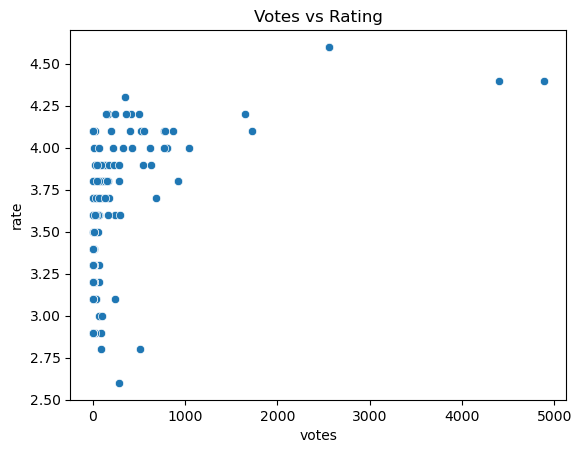

In [170]:
# Analyze relationship between votes and rating

sns.scatterplot(
    data=df,
    x='votes',
    y='rate'
)

plt.title("Votes vs Rating")

plt.show()

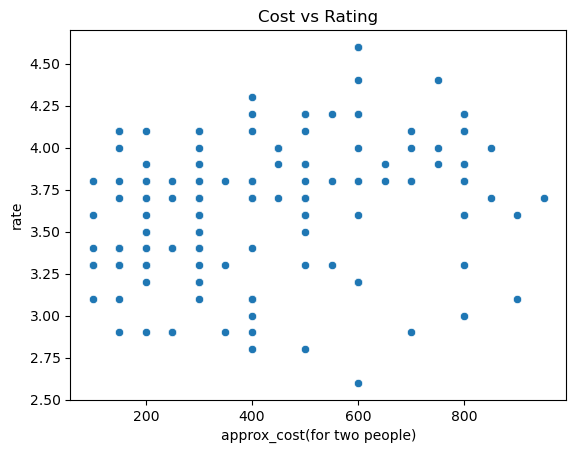

In [172]:
# Analyze relationship between cost and rating

sns.scatterplot(
    data=df,
    x='approx_cost(for two people)',
    y='rate'
)

plt.title("Cost vs Rating")

plt.show()

In [174]:
# Calculate correlations

numeric_df = df[
    [
        'rate',
        'votes',
        'approx_cost(for two people)'
    ]
]

numeric_df.corr()

,rate,votes,approx_cost(for two people)
rate,1.000000,0.489844,0.275216
votes,0.489844,1.000000,0.324372
approx_cost(for two people),0.275216,0.324372,1.000000


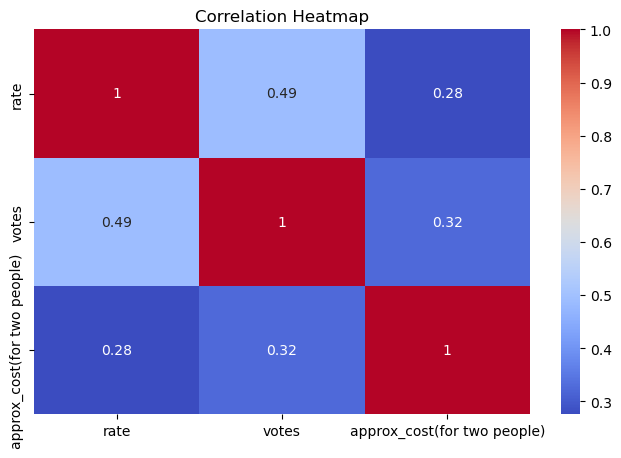

In [176]:
# Visualize correlations

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [178]:
# Create popularity score

df['Popularity_Score'] = (
    df['rate'] * df['votes']
)

df[['Popularity_Score']].head()

,Popularity_Score
0,3177.5
1,3226.7
2,3488.4
3,325.6
4,630.8


In [180]:
# Create premium restaurant flag

df['Premium_Restaurant'] = (
    df['approx_cost(for two people)'] > 600
).astype(int)

df[['Premium_Restaurant']].head()

,Premium_Restaurant
0,1
1,1
2,1
3,0
4,0


In [182]:
# Create rating categories

df['Rating_Category'] = pd.cut(
    df['rate'],
    bins=[0,3,4,5],
    labels=['Low','Medium','High']
)

df[['rate','Rating_Category']].head()

,rate,Rating_Category
0,4.1,High
1,4.1,High
2,3.8,Medium
3,3.7,Medium
4,3.8,Medium


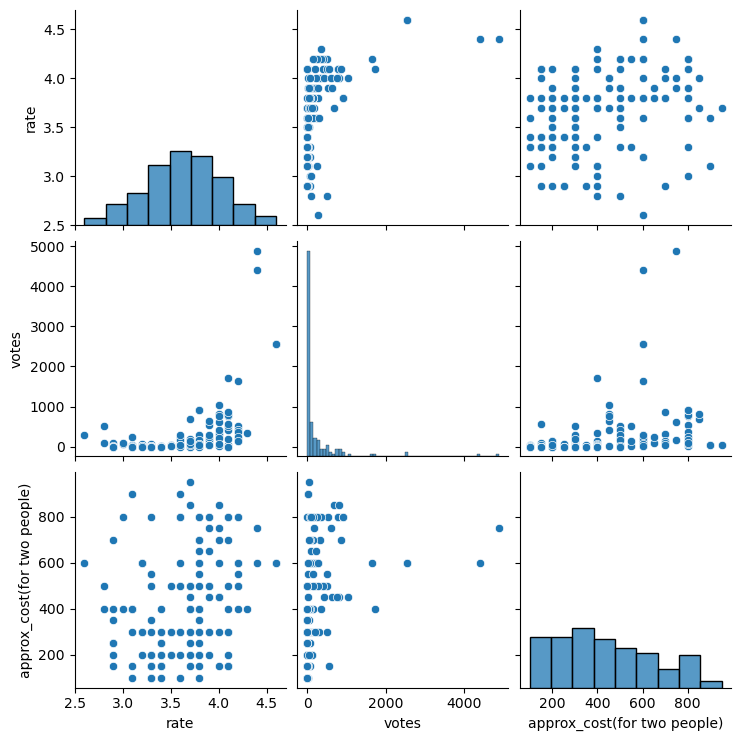

In [184]:
# Perform multivariate analysis

sns.pairplot(
    numeric_df
)

plt.show()

In [186]:
# Generate project summary

print("Average Rating:", round(df['rate'].mean(),2))
print("Average Votes:", round(df['votes'].mean(),2))
print("Average Cost:", round(df['approx_cost(for two people)'].mean(),2))

Average Rating: 3.63
Average Votes: 264.81
Average Cost: 418.24
